Nom :   Khadijetou Mohamed abe    

Filière :  GLCC

-------------------------------------------------------------TP ML------------------------------------------------------------------

# Objectif :

Ce travail présente l'implémentation "from scratch" des modèles de régression linéaire (simple, multiple et polynomiale) utilisant la descente de gradient, ainsi qu'une comparaison systématique de leurs performances avec celles de la bibliothèque sklearn.

Pour présenter ce travail de manière structurée, l'organisation choisie est la suivante :

    1. Code scratch des fonctions de régression (modèle, gradient, Algorithme de descente de gradient) qui s'adaptent automatiquement aux dimensions des données selon chaque type de régression

    2. PARTIE 1 : Régression linéaire simple
            a. Jeu de données (DATASET)
            b. Exécution du code scratch
            c. Code sklearn
            d. Comparaison et graphiques (scratch/sklearn)

    3. PARTIE 2 : Régression linéaire multiple (même structure)
    
    4. PARTIE 3 : Régression polynomiale (même structure)


# 1.CODE SCRATCH

Ces fonctions sont définies une seule fois. Grâce à l'algèbre linéaire, elles s'adaptent 
automatiquement à 1, 3 ou N variables (n_features), ainsi qu'aux transformations polynomiales.


In [67]:
import numpy as np
import matplotlib.pyplot as plt


# a. MODÈLE
def model(X, W):
    """
    Modèle linéaire de la forme f(x) = X.W 
    - En simple : f(xi) = w1*xi + w0
    - En multiple : f(xi) = w0 + w1*xi1 + w2*xi2 + w3*xi3....wn*xin 
    - En polynomial : f(xi) = w0 + w1*xi + w2*xi**2.....wn*xi**n  (X doit dénjà contenir les puissances de x)
    Équivalent au produit matriciel X.W, retourne y_predict de taille (n_samples, 1) 
    """
    return X.dot(W)


# b. Gradient
def calcul_gradient(X, y, W):
    n = len(y)                         
    y_predict = model(X, W)            # prédiction du modèle pour calculer l'erreur par rapport au réel
    erreur = y_predict - y             
    grad = (1 / n) * X.T.dot(erreur)   # gradient ∇J(W) = d/dw ( (1 / (2n)) * (X.W - y)**2),retourne (n_features+1,1)
    return grad


# c. Algorithme de descente de gradient
# le pas, epsilon et k_max (max itérations) comme arguments pour pouvoir les modifier si besoin
def descente_gradient(X, y, pas=0.1, epsilon=10**-3, k_max=1000):
    W = np.zeros((X.shape[1], 1))      # initialisation de W à 0 (n_features+1,1)
    k = 0                              
    grad = calcul_gradient(X, y, W)    # calcule le gradient pour W initial

    # Arrêt quand le gradient devient très petit (convergence) ou si on dépasse le kmax
    while np.linalg.norm(grad) > epsilon and k < k_max:
        W = W - pas * grad                 # mise à jour de W avec le pas d'apprentissage
        grad = calcul_gradient(X, y, W)    
        k += 1
    print("itération k=",k)
    return W



# PARTIE 1: RÉGRESSION LINÉAIRE SIMPLE

make_regression  a été utilisé pour créer un grand jeu de données plutôt que de le faire manuellement.
Cela permet de mieux tester notre fonction sur un dataset important (+100 points).
Nous avons donc 100 points avec une seule (feature) -pour la régression simple.
Et comme la fonction retourne un tuple (X, Y) de (100, 1) et (100,), donc on redimensionne Y en (100, 1) pour assurer la compatibilité 
matricielle avec X lors des calculs.


## a. DATASET pour la régression linéaire

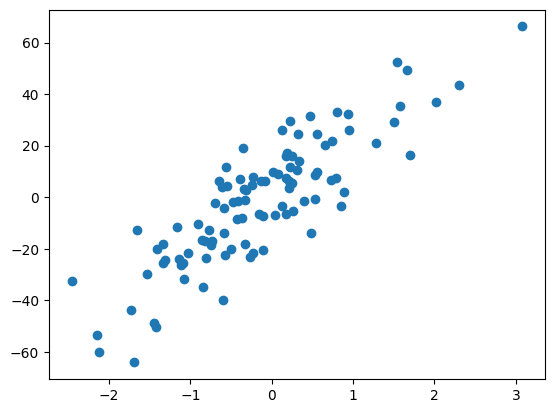

In [46]:
from sklearn.datasets import make_regression
X_data_simple, Y_real_simple = make_regression(n_samples=100, n_features=1, noise=15)
Y_real_simple = Y_real_simple.reshape(Y_real_simple.shape[0], 1)

plt.scatter(X_data_simple, Y_real_simple)
plt.show()

## b. Exécution du code scratch

In [48]:
# Ajouter la colonne I=1 à X pour obtenir (100,2)
X_simple = np.hstack((np.ones((X_data_simple.shape[0], 1)), X_data_simple))

# W optimal après optimisation par GD
W_simple = descente_gradient(X_simple, Y_real_simple, pas=0.1)

# Droite de prédiction finale
predictions_scratch_simple = X_simple.dot(W_simple)

itération k= 109


## c. Code sklearn

In [50]:
from sklearn.linear_model import LinearRegression
modele_sklearn_simple = LinearRegression()
modele_sklearn_simple.fit(X_data_simple, Y_real_simple)    # application sur le même DATASET

predictions_sklearn_simple = modele_sklearn_simple.predict(X_data_simple)

## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des paramètres W
Scratch : [[ 1.3909252  21.35131252]] | Sklearn : [1.39170133] [[21.35220098]]


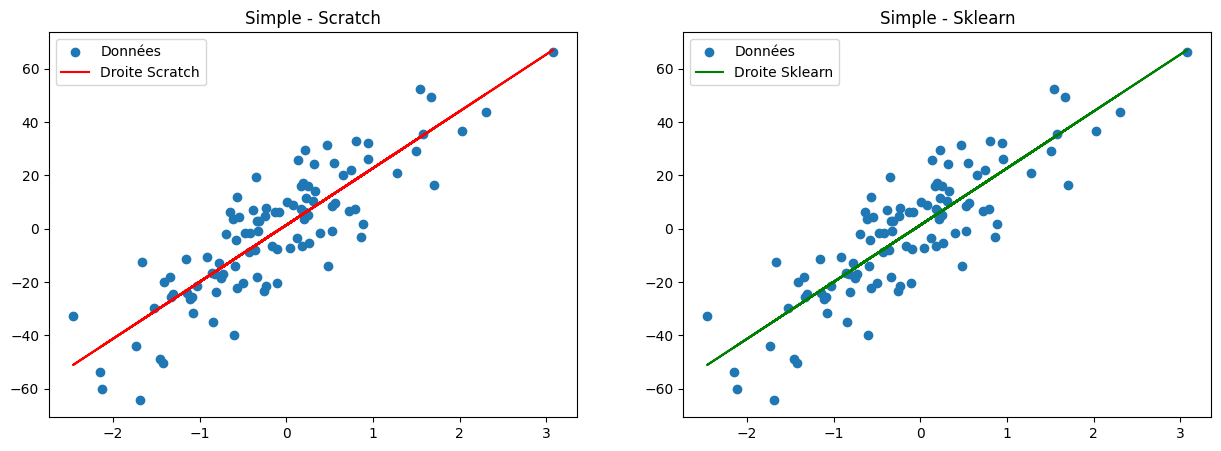

In [51]:
print("Comparaison des paramètres W")
print("Scratch :", W_simple.T, "| Sklearn :", modele_sklearn_simple.intercept_, modele_sklearn_simple.coef_)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_data_simple, Y_real_simple,  label='Données')
plt.plot(X_data_simple, predictions_scratch_simple,'r', label='Droite Scratch')
plt.title('Simple - Scratch')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_data_simple, Y_real_simple, label='Données')
plt.plot(X_data_simple, predictions_sklearn_simple, 'g', label='Droite Sklearn')
plt.title('Simple - Sklearn')
plt.legend()
plt.show()


# PARTIE 2: RÉGRESSION LINÉAIRE MULTIPLE

Comme pour la régression simple, on utilise make_regression. La seule différence est (n_features=3). 


## a. DATASET pour la régression linéaire multiple

In [53]:
X_data_multi, Y_real_multi = make_regression(n_samples=100, n_features=3, noise=15)
Y_real_multi = Y_real_multi.reshape(Y_real_multi.shape[0], 1)         # pour passer de (100,) à (100,1)

## b. Exécution du code scratch

In [54]:
# La matrice passe à (100, 4) car on ajoute la colonne de 1.
X_multi = np.hstack((np.ones((X_data_multi.shape[0], 1)), X_data_multi))
W_multi = descente_gradient(X_multi, Y_real_multi, pas=0.1)
predictions_scratch_multi = X_multi.dot(W_multi)

itération k= 153


## c. Code sklearn

In [55]:
modele_sklearn_multi = LinearRegression()
modele_sklearn_multi.fit(X_data_multi, Y_real_multi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## d. Comparaison (scratch/sklearn)


En régression multiple, on ne peut plus tracer une droite dans un plan 2D ou 3D à cause des 3 features,
ce qui correspondrait à un espace 4D.  
On va donc seulement comparer les paramètres trouvés.


In [56]:

print("Comparaison des paramètres W")
print("Scratch :", W_multi.T, "| Sklearn :", modele_sklearn_multi.intercept_, modele_sklearn_multi.coef_)


Comparaison des paramètres W
Scratch : [[ 1.52513922 90.90908166 -0.38241649 37.19873923]] | Sklearn : [1.52539999] [[90.90995914 -0.38347433 37.19848726]]



# PARTIE 3: RÉGRESSION POLYNOMIALE

Pour ce cas, make_regression n'est pas adapté car il crée des données linéaires.
Nous allons donc créer manuellement un DATASET qui suit une courbe (un polynôme de degré 2),
en y ajoutant un bruit aléatoire afin de le rendre plus réaliste.
L'équation sera de la forme : y = a*x^2 + b*x + c + bruit (noise).

## a. DATASET pour la régression polynomiale

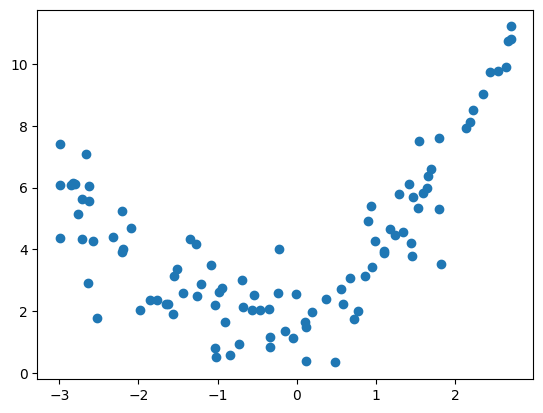

In [62]:
X_data_poly = 6 * np.random.rand(100, 1) - 3 
Y_real_poly = 0.8 * X_data_poly**2 + X_data_poly + 2 + np.random.randn(100, 1) 

plt.scatter(X_data_poly, Y_real_poly)
plt.show()

## b. Exécution du code scratch

Pour un polynôme de degré 2, on crée 3 colonnes : X^0 (1), X^1 (linéaire) et X^2 (quadratique).
La matrice X aura donc une taille de (100, 3).


In [63]:
# Création de X polynomiale manuellement
X_poly_scratch = np.hstack((np.ones((X_data_poly.shape[0], 1)), X_data_poly, X_data_poly**2))
W_poly = descente_gradient(X_poly_scratch, Y_real_poly) 

itération k= 149


## c. Code sklearn

In [64]:
from sklearn.preprocessing import PolynomialFeatures
# Scikit-learn a un outil dédié pour créer le X polynomiale
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly_sklearn = poly_features.fit_transform(X_data_poly)
modele_sklearn_poly = LinearRegression()
modele_sklearn_poly.fit(X_poly_sklearn, Y_real_poly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## d. Comparaison et graphiques (scratch/sklearn)

Comparaison des paramètres W 
Scratch : [[2.05861513 0.98215983 0.80882086]] | Sklearn : [2.06085218] [[0.98200247 0.80837588]]


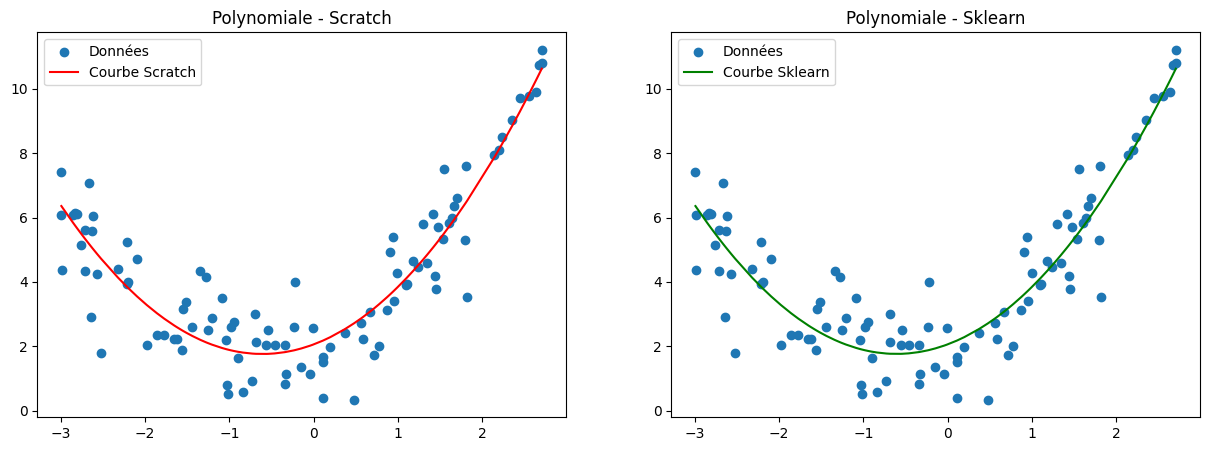

In [66]:
print("Comparaison des paramètres W ")
print("Scratch :", W_poly.T, "| Sklearn :", modele_sklearn_poly.intercept_, modele_sklearn_poly.coef_)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_data_poly, Y_real_poly, label='Données')
# Représente la prédiction et trie les données pour le tracé
plt.plot(X_data_poly[np.argsort(X_data_poly, axis=0).flatten()], model(X_poly_scratch, W_poly)[np.argsort(X_data_poly, axis=0).flatten()], 'r', label='Courbe Scratch')
plt.title('Polynomiale - Scratch')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_data_poly, Y_real_poly, label='Données')
plt.plot(X_data_poly[np.argsort(X_data_poly, axis=0).flatten()], modele_sklearn_poly.predict(X_poly_sklearn)[np.argsort(X_data_poly, axis=0).flatten()], 'g', label='Courbe Sklearn')
plt.title('Polynomiale - Sklearn')
plt.legend()

plt.show()